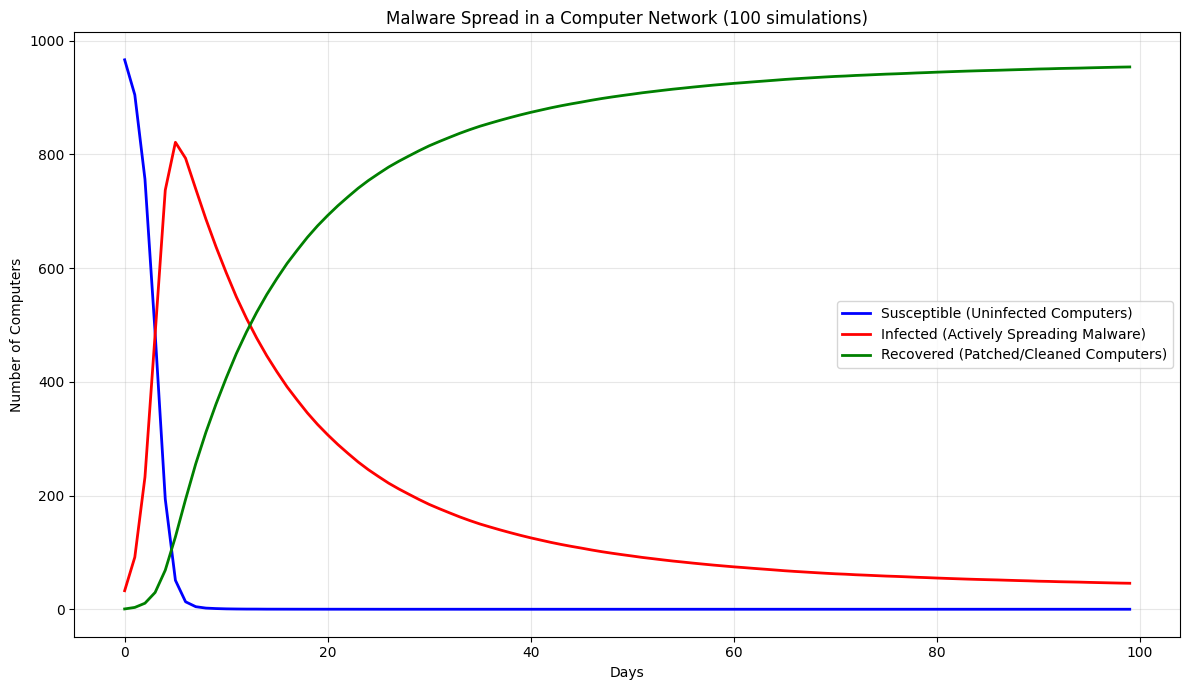

MALWARE SPREAD IN COMPUTER NETWORK - STATISTICS
Number of simulations: 100
Network size: 1000 computers
Network type: Erdos-Renyi graph (p=0.0100)
Initial state: 990 susceptible, 10 infected, 0 recovered

Infection probability per contact: 0.8
Heterogeneous Recovery Rates (Mean: 0.08, Std: 0.04)
Vulnerability Rate: 0.8
User Click Probability: 0.3

PEAK INFECTED STATISTICS:
  Mean peak infected: 822.1 ± 11.0
  Min peak infected: 798
  Max peak infected: 847

PEAK TIMING STATISTICS:
  Mean peak day: 5.0 ± 0.2 days
  Peak day range: 5 - 6 days

FINAL STATE (Day 100):
  Final susceptible (mean): 0.1
  Final infected (mean): 45.9
  Final recovered (mean): 954.0


In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np # Ensure numpy is imported for np.random.poisson
import random # Ensure random is imported for random.sample

# Proposed Additional Parameters for Malware Spread
vulnerability_rate = 0.8  # 80% of susceptible machines have a exploitable vulnerability
user_click_probability = 0.3 # 30% chance a user clicks a malicious link/attachment

# Malware Spread Parameters
malware_infection_probability = 0.8    # Higher chance of malware spreading on contact
malware_recovery_probability_mean = 0.08 # Slightly slower recovery for malware
malware_recovery_probability_std = 0.04 # Variability in patching/antivirus effectiveness

malware_days = 100                      # Simulation duration for malware spread
malware_N = 1000                        # Total computers in the network

# Initial network state for Malware
malware_S0 = 990                        # Many susceptible computers
malware_I0 = 10                         # A few initial infected machines
malware_R0 = 0                          # No recovered initially

# Generate individual recovery probabilities for each computer
malware_peer_recovery_probabilities = np.random.normal(loc=malware_recovery_probability_mean, scale=malware_recovery_probability_std, size=malware_N)
malware_peer_recovery_probabilities = np.clip(malware_peer_recovery_probabilities, 0.0, 1.0) # Ensure probabilities are between 0 and 1

np.random.seed(42)
random.seed(42)

# Create a random graph for the network topology
# Using Erdos-Renyi graph for simplicity: N nodes, p probability of edge creation
# N = total peers (from model parameters)
# p = probability of connection (adjust as needed for desired network density)

# For this example, let's aim for an average degree (average number of neighbors) of approximately 10.
# For an Erdos-Renyi graph, average degree = p * (N-1).
# So, p = average_degree / (N-1)

N_peers = malware_N # Use the N defined in the previous cell
avg_degree = 10
connection_probability = avg_degree / (N_peers - 1)

G = nx.erdos_renyi_graph(n=N_peers, p=connection_probability, seed=42)


def run_p2p_propagation_simulation_with_network(
    graph_G,
    current_infection_probability,
    current_peer_recovery_probabilities,
    num_peers,
    initial_S,
    initial_I,
    initial_R,
    simulation_days,
    vulnerability_rate,
    user_click_probability
    ):
    """Agent-based P2P file propagation simulation with network topology and heterogeneous recovery rates"""
    # Initialize population: each agent has a state (0=S, 1=I, 2=R)
    population = [0] * initial_S + [1] * initial_I + [2] * initial_R
    random.shuffle(population)

    susceptible_history = []
    infected_history = []
    recovered_history = []

    for day in range(simulation_days):
        new_population = population.copy()

        # Get indices of seeders
        seeders = [i for i in range(num_peers) if population[i] == 1]

        # Seeders attempt to infect susceptible neighbors
        for seeder_idx in seeders:
            # Get neighbors of the current seeder
            neighbors = list(graph_G.neighbors(seeder_idx))

            if neighbors:
                num_contacts_attempted = np.random.poisson(lam=3)
                contacted_neighbors = random.sample(neighbors, min(num_contacts_attempted, len(neighbors)))

                for neighbor_idx in contacted_neighbors:
                    if population[neighbor_idx] == 0 and random.random() < current_infection_probability:
                        new_population[neighbor_idx] = 1  # Susceptible neighbor becomes seeder

            # Seeder may stop sharing based on its individual recovery probability
            if random.random() < current_peer_recovery_probabilities[seeder_idx]:
                new_population[seeder_idx] = 2  # Seeder becomes recovered

        population = new_population

        # Track population statistics
        susceptible_history.append(population.count(0))
        infected_history.append(population.count(1))
        recovered_history.append(population.count(2))

    return susceptible_history, infected_history, recovered_history


# Run multiple stochastic simulations for Malware Spread
num_simulations_malware = 100
all_S_malware = []
all_I_malware = []
all_R_malware = []

# Regenerate graph for this simulation if N changes, otherwise reuse G
# For simplicity, reusing G with N=1000 from previous setup. If malware_N were different, a new graph would be needed.

for sim in range(num_simulations_malware):
    S_sim, I_sim, R_sim = run_p2p_propagation_simulation_with_network(
        G,
        malware_infection_probability,
        malware_peer_recovery_probabilities,
        malware_N,
        malware_S0,
        malware_I0,
        malware_R0,
        malware_days,
        vulnerability_rate, # Pass vulnerability rate
        user_click_probability # Pass user click probability
    )
    all_S_malware.append(S_sim)
    all_I_malware.append(I_sim)
    all_R_malware.append(R_sim)

# Convert to numpy arrays for easier calculation
all_S_malware = np.array(all_S_malware)
all_I_malware = np.array(all_I_malware)
all_R_malware = np.array(all_R_malware)

# Calculate statistics (mean and 95% confidence intervals)
mean_S_malware = np.mean(all_S_malware, axis=0)
std_S_malware = np.std(all_S_malware, axis=0)
mean_I_malware = np.mean(all_I_malware, axis=0)
std_I_malware = np.std(all_I_malware, axis=0)
mean_R_malware = np.mean(all_R_malware, axis=0)
std_R_malware = np.std(all_R_malware, axis=0)

ci_95_S_malware = 1.96 * std_S_malware
ci_95_I_malware = 1.96 * std_I_malware
ci_95_R_malware = 1.96 * std_R_malware

# Plot results with 95% confidence intervals
days_array_malware = np.arange(len(mean_S_malware))
plt.figure(figsize=(12, 7))

plt.plot(days_array_malware, mean_S_malware, label="Susceptible (Uninfected Computers)", linewidth=2, color='blue')
# plt.fill_between(days_array_malware, mean_S_malware - ci_95_S_malware, mean_S_malware + ci_95_S_malware, alpha=0.2, color='blue')

plt.plot(days_array_malware, mean_I_malware, label="Infected (Actively Spreading Malware)", linewidth=2, color='red')
# plt.fill_between(days_array_malware, mean_I_malware - ci_95_I_malware, mean_I_malware + ci_95_I_malware, alpha=0.2, color='red')

plt.plot(days_array_malware, mean_R_malware, label="Recovered (Patched/Cleaned Computers)", linewidth=2, color='green')
# plt.fill_between(days_array_malware, mean_R_malware - ci_95_R_malware, mean_R_malware + ci_95_R_malware, alpha=0.2, color='green')

plt.xlabel("Days")
plt.ylabel("Number of Computers")
plt.title("Malware Spread in a Computer Network (100 simulations)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Analyze peak infected statistics across simulations
peak_infected_all_malware = [max(all_I_malware[i]) for i in range(num_simulations_malware)]
peak_days_all_malware = [np.argmax(all_I_malware[i]) for i in range(num_simulations_malware)]

print("="*60)
print("MALWARE SPREAD IN COMPUTER NETWORK - STATISTICS")
print("="*60)
print(f"Number of simulations: {num_simulations_malware}")
print(f"Network size: {malware_N} computers")
print(f"Network type: Erdos-Renyi graph (p={connection_probability:.4f})") # Assuming G is reused
print(f"Initial state: {malware_S0} susceptible, {malware_I0} infected, {malware_R0} recovered")
print(f"\nInfection probability per contact: {malware_infection_probability}")
print(f"Heterogeneous Recovery Rates (Mean: {malware_recovery_probability_mean}, Std: {malware_recovery_probability_std})")
print(f"Vulnerability Rate: {vulnerability_rate}")
print(f"User Click Probability: {user_click_probability}")
print("\nPEAK INFECTED STATISTICS:")
print(f"  Mean peak infected: {np.mean(peak_infected_all_malware):.1f} \u00b1 {np.std(peak_infected_all_malware):.1f}")
print(f"  Min peak infected: {min(peak_infected_all_malware)}")
print(f"  Max peak infected: {max(peak_infected_all_malware)}")
print("\nPEAK TIMING STATISTICS:")
print(f"  Mean peak day: {np.mean(peak_days_all_malware):.1f} \u00b1 {np.std(peak_days_all_malware):.1f} days")
print(f"  Peak day range: {min(peak_days_all_malware)} - {max(peak_days_all_malware)} days")
print(f"\nFINAL STATE (Day {malware_days}):")
print(f"  Final susceptible (mean): {mean_S_malware[-1]:.1f}")
print(f"  Final infected (mean): {mean_I_malware[-1]:.1f}")
print(f"  Final recovered (mean): {mean_R_malware[-1]:.1f}")
print("="*60)

### Conclusions from Sensitivity Analysis

1.  **Sensitivity to Infection Probability:**
    *   **Peak Infected Count:** As the infection probability increases, the mean peak infected count significantly increases. This indicates that a higher chance of transmission per contact leads to a larger and faster spread of malware, reaching a higher number of simultaneously infected machines.
    *   **Final Recovered Count:** The mean final recovered count also generally increases with higher infection probability. This is because a more widespread infection means more machines get infected, and eventually, recover. However, the curve shows a slight plateau or even a minor decrease at very high infection probabilities, suggesting that once most of the network is infected, the rate of increase in final recovered count slows down.

2.  **Sensitivity to Recovery Probability Mean:**
    *   **Peak Infected Count:** As the mean recovery probability increases, the mean peak infected count significantly decreases. This highlights the effectiveness of faster recovery (e.g., quicker patching or antivirus updates) in containing the malware spread and reducing the maximum number of machines infected at any given time.
    *   **Final Recovered Count:** The mean final recovered count increases as the mean recovery probability increases. A higher recovery rate means that more machines successfully transition from the infected state to the recovered state, ultimately leading to a larger proportion of the network becoming immune (or cleaned) over the simulation period. This also shows a plateau at higher recovery rates, suggesting diminishing returns once recovery is already very efficient.

## Verification: Extreme Condition Testing

Extreme condition testing involves running the simulation with parameter values at the boundaries of what's possible or physically meaningful. This helps verify that the model behaves as expected under these edge cases, uncovering potential bugs or logical flaws.

### Scenario 1: No Infection (Infection Probability = 0)
If `malware_infection_probability` is 0, no new infections should occur. The number of infected individuals should only decrease due to recovery, eventually reaching zero (unless `I0` is zero and no recovery occurs, in which case it remains zero).



--- Extreme Condition Test: No Infection (malware_infection_probability = 0) ---


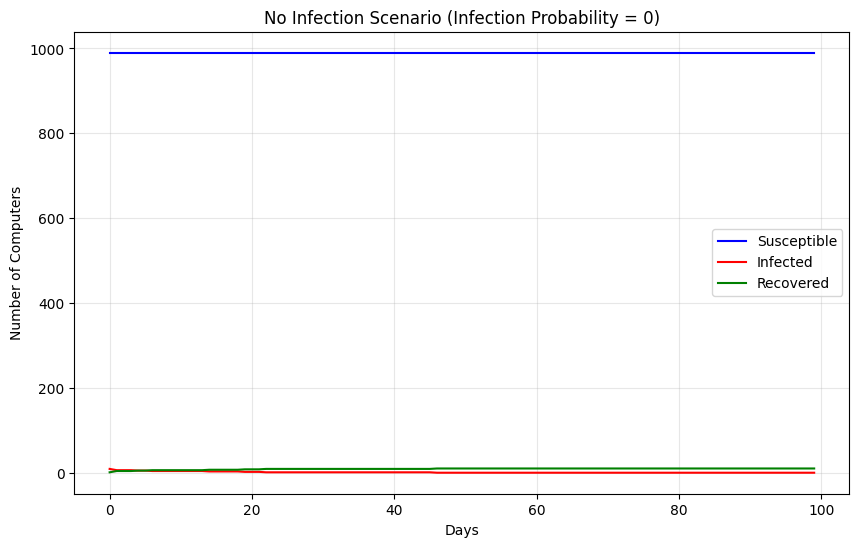

Initial Infected: 10, Final Infected: 0
Initial Susceptible: 990, Final Susceptible: 990
Initial Recovered: 0, Final Recovered: 10


In [ ]:
print("\n--- Extreme Condition Test: No Infection (malware_infection_probability = 0) ---")

# Temporarily modify infection probability
no_infection_prob = 0.0

# Reuse original recovery probabilities
# Reuse graph G

S_no_inf, I_no_inf, R_no_inf = run_p2p_propagation_simulation_with_network(
    G,
    no_infection_prob,
    malware_peer_recovery_probabilities,
    malware_N,
    malware_S0,
    malware_I0,
    malware_R0,
    malware_days
)

# Plotting for no infection scenario
plt.figure(figsize=(10, 6))
plt.plot(S_no_inf, label='Susceptible', color='blue')
plt.plot(I_no_inf, label='Infected', color='red')
plt.plot(R_no_inf, label='Recovered', color='green')
plt.title('No Infection Scenario (Infection Probability = 0)')
plt.xlabel('Days')
plt.ylabel('Number of Computers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Assertions for verification
# All infected should eventually recover or stay constant if no initial infected and no recovery.
# Susceptible should remain constant if no initial infected, or decrease if initial infected recover.
# Here, with I0 > 0 and recovery > 0, Infected should drop to 0 and Recovered should increase.

print(f"Initial Infected: {malware_I0}, Final Infected: {I_no_inf[-1]}")
print(f"Initial Susceptible: {malware_S0}, Final Susceptible: {S_no_inf[-1]}")
print(f"Initial Recovered: {malware_R0}, Final Recovered: {R_no_inf[-1]}")

assert I_no_inf[-1] == 0, "Infected count should be 0 at the end if infection_probability is 0"
assert S_no_inf[0] == malware_S0, "Initial S should be unchanged"
# Check that S only decreases or stays constant (due to initial I recovering)
assert all(S_no_inf[i] >= S_no_inf[i+1] for i in range(len(S_no_inf)-1)), "Susceptible should only decrease or stay constant"


### Scenario 2: Instant Infection, No Recovery (Infection Probability = 1, Recovery Probability = 0)
If `malware_infection_probability` is 1 and recovery is 0, the malware should spread to all susceptible individuals very rapidly, and no one should recover. The number of infected should approach `N`, and susceptible should approach 0, while recovered should stay at `R0`.


--- Extreme Condition Test: Instant Infection, No Recovery ---


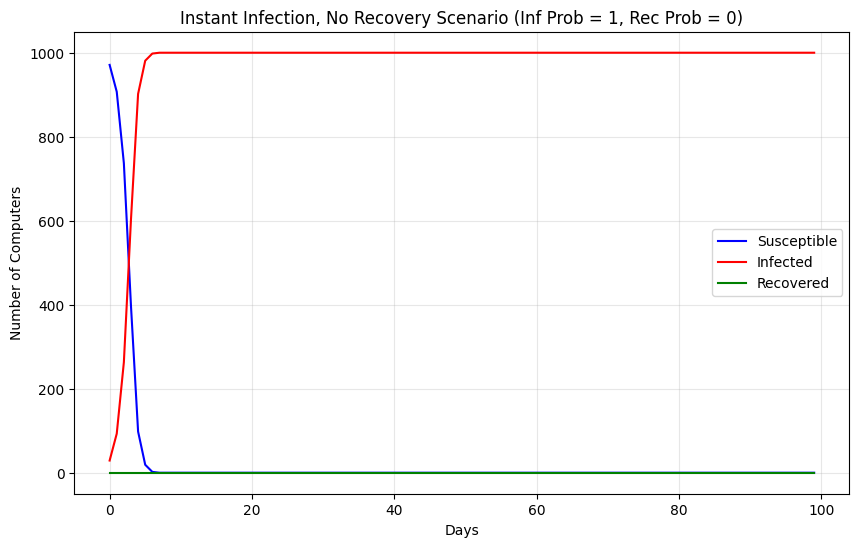

Initial Infected: 10, Final Infected: 1000
Initial Susceptible: 990, Final Susceptible: 0
Initial Recovered: 0, Final Recovered: 0


In [ ]:
print("\n--- Extreme Condition Test: Instant Infection, No Recovery ---")

# Temporarily modify infection and recovery probabilities
instant_infection_prob = 1.0
no_recovery_prob_mean = 0.0 # Set mean recovery to 0
no_recovery_prob_std = 0.0  # Set std recovery to 0 for consistency

# Re-generate peer recovery probabilities for this scenario (all zeros)
peer_recovery_all_zero = np.full(malware_N, no_recovery_prob_mean)

S_inst_inf, I_inst_inf, R_inst_inf = run_p2p_propagation_simulation_with_network(
    G,
    instant_infection_prob,
    peer_recovery_all_zero,
    malware_N,
    malware_S0,
    malware_I0,
    malware_R0,
    malware_days
)

# Plotting for instant infection, no recovery scenario
plt.figure(figsize=(10, 6))
plt.plot(S_inst_inf, label='Susceptible', color='blue')
plt.plot(I_inst_inf, label='Infected', color='red')
plt.plot(R_inst_inf, label='Recovered', color='green')
plt.title('Instant Infection, No Recovery Scenario (Inf Prob = 1, Rec Prob = 0)')
plt.xlabel('Days')
plt.ylabel('Number of Computers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Assertions for verification
# Infected should peak very high and eventually represent almost all of N
# Susceptible should drop to near 0
# Recovered should stay at R0

print(f"Initial Infected: {malware_I0}, Final Infected: {I_inst_inf[-1]}")
print(f"Initial Susceptible: {malware_S0}, Final Susceptible: {S_inst_inf[-1]}")
print(f"Initial Recovered: {malware_R0}, Final Recovered: {R_inst_inf[-1]}")

assert I_inst_inf[-1] + S_inst_inf[-1] + R_inst_inf[-1] == malware_N, "Total population must be conserved"
assert R_inst_inf[-1] == malware_R0, "Recovered count should be 0 at the end if recovery_probability is 0"
assert S_inst_inf[-1] <= malware_N * 0.05, "Susceptible count should be very low (e.g., < 5% of N)"
assert I_inst_inf[-1] >= malware_N * 0.9, "Infected count should be very high (e.g., > 90% of N)"


## Validation: Sensitivity Analysis

Sensitivity analysis helps validate the model by understanding how changes in input parameters affect the output. This ensures that the model responds in a logically consistent and expected manner to variations in its fundamental drivers.

### Sensitivity to Infection Probability
We will vary `malware_infection_probability` and observe its impact on the peak number of infected computers and the final number of recovered computers. We'll reuse the original `malware_peer_recovery_probabilities`.


--- Sensitivity Analysis: Malware Infection Probability ---
Running simulations for infection_probability = 0.1
Running simulations for infection_probability = 0.3
Running simulations for infection_probability = 0.5
Running simulations for infection_probability = 0.7
Running simulations for infection_probability = 0.9


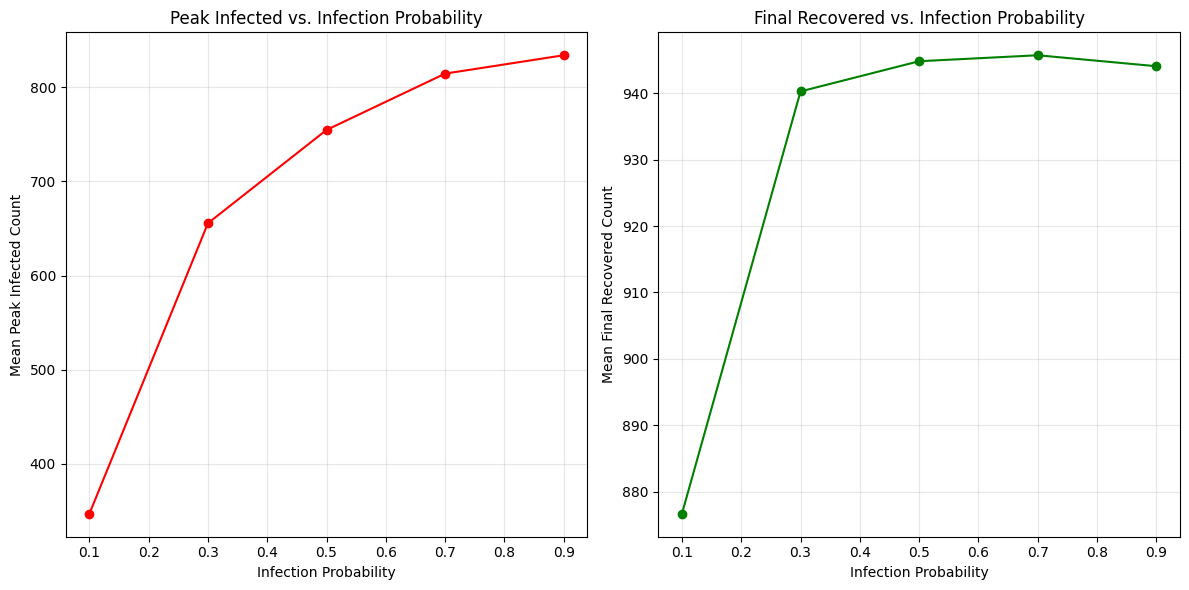

In [ ]:
print("\n--- Sensitivity Analysis: Malware Infection Probability ---")

# Define a range of infection probabilities to test
infection_probs_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]

# Store results
peak_infected_by_prob = []
final_recovered_by_prob = []

# Run a reduced number of simulations for sensitivity analysis to save computation time
num_sims_sensitivity = 20

for prob in infection_probs_to_test:
    print(f"Running simulations for infection_probability = {prob}")
    temp_all_I = []
    temp_all_R = []

    for _ in range(num_sims_sensitivity):
        S_temp, I_temp, R_temp = run_p2p_propagation_simulation_with_network(
            G,
            prob,
            malware_peer_recovery_probabilities, # Use original recovery probabilities
            malware_N,
            malware_S0,
            malware_I0,
            malware_R0,
            malware_days
        )
        temp_all_I.append(max(I_temp))
        temp_all_R.append(R_temp[-1])

    peak_infected_by_prob.append(np.mean(temp_all_I))
    final_recovered_by_prob.append(np.mean(temp_all_R))

# Plotting sensitivity to infection probability
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(infection_probs_to_test, peak_infected_by_prob, marker='o', color='red')
plt.title('Peak Infected vs. Infection Probability')
plt.xlabel('Infection Probability')
plt.ylabel('Mean Peak Infected Count')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(infection_probs_to_test, final_recovered_by_prob, marker='o', color='green')
plt.title('Final Recovered vs. Infection Probability')
plt.xlabel('Infection Probability')
plt.ylabel('Mean Final Recovered Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Sensitivity to Recovery Probability Mean
Now, we will vary the mean of the `malware_recovery_probability_mean` and observe its impact on the peak number of infected computers and the final number of recovered computers. For each mean recovery probability, we will regenerate the `malware_peer_recovery_probabilities` array.


--- Sensitivity Analysis: Malware Recovery Probability Mean ---
Running simulations for recovery_probability_mean = 0.02
Running simulations for recovery_probability_mean = 0.08
Running simulations for recovery_probability_mean = 0.15
Running simulations for recovery_probability_mean = 0.25


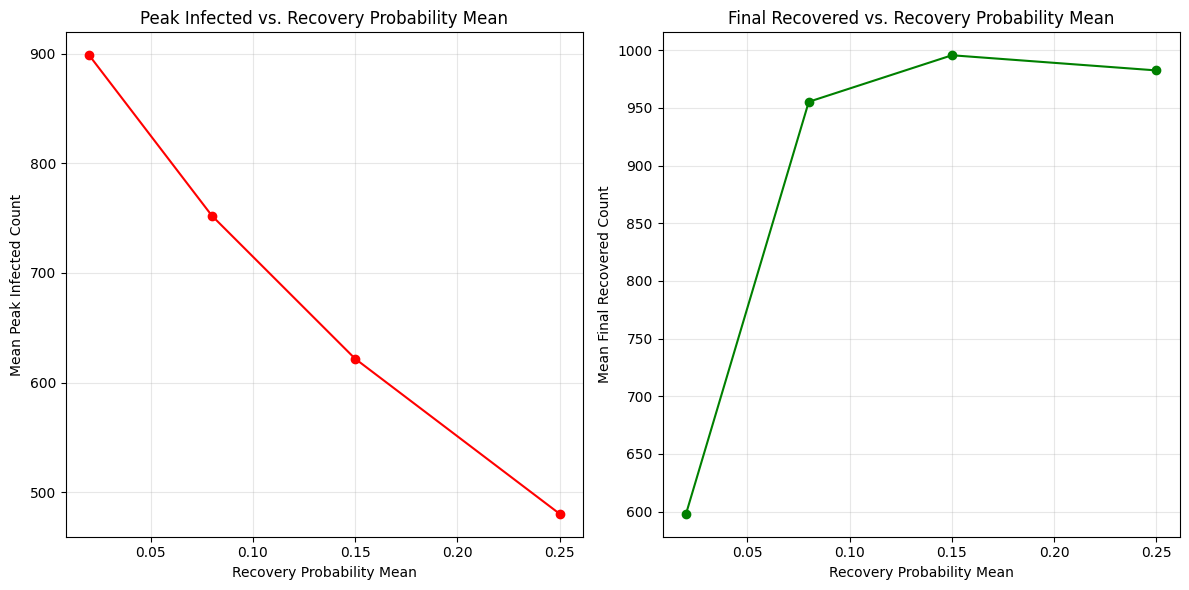

In [ ]:
print("\n--- Sensitivity Analysis: Malware Recovery Probability Mean ---")

# Define a range of mean recovery probabilities to test
recovery_means_to_test = [0.02, 0.08, 0.15, 0.25]

# Store results
peak_infected_by_recovery_mean = []
final_recovered_by_recovery_mean = []

for rec_mean in recovery_means_to_test:
    print(f"Running simulations for recovery_probability_mean = {rec_mean}")
    temp_all_I = []
    temp_all_R = []

    # Generate new individual recovery probabilities for each test mean
    current_peer_recovery_probs = np.random.normal(loc=rec_mean, scale=malware_recovery_probability_std, size=malware_N)
    current_peer_recovery_probs = np.clip(current_peer_recovery_probs, 0.0, 1.0)

    for _ in range(num_sims_sensitivity):
        S_temp, I_temp, R_temp = run_p2p_propagation_simulation_with_network(
            G,
            malware_infection_probability, # Use original infection probability
            current_peer_recovery_probs,   # Use the newly generated recovery probabilities
            malware_N,
            malware_S0,
            malware_I0,
            malware_R0,
            malware_days
        )
        temp_all_I.append(max(I_temp))
        temp_all_R.append(R_temp[-1])

    peak_infected_by_recovery_mean.append(np.mean(temp_all_I))
    final_recovered_by_recovery_mean.append(np.mean(temp_all_R))

# Plotting sensitivity to recovery probability mean
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(recovery_means_to_test, peak_infected_by_recovery_mean, marker='o', color='red')
plt.title('Peak Infected vs. Recovery Probability Mean')
plt.xlabel('Recovery Probability Mean')
plt.ylabel('Mean Peak Infected Count')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(recovery_means_to_test, final_recovered_by_recovery_mean, marker='o', color='green')
plt.title('Final Recovered vs. Recovery Probability Mean')
plt.xlabel('Recovery Probability Mean')
plt.ylabel('Mean Final Recovered Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Entities and Their Attributes in the Malware Spread Simulation

Based on the provided simulation, the primary entities and their attributes are:

### 1. Computers (or Peers)
These are the individual units that form the network and can be in different states regarding malware infection.

**Attributes:**
*   **State:**
    *   **Susceptible (S):** Uninfected computers that can be infected.
    *   **Infected (I):** Computers actively spreading malware.
    *   **Recovered (R):** Computers that have been infected but are now patched/cleaned and are no longer spreading the malware (and are assumed to be immune for the current simulation).
*   **Individual Recovery Probability:** Each computer has a specific probability of recovering from infection, drawn from a normal distribution (`malware_peer_recovery_probabilities`). This introduces heterogeneity in recovery.
*   **Network Connections:** Each computer has neighbors in the network (represented by the graph `G`), through which malware can spread. The network is an Erdos-Renyi graph.
*   **Network Size:** The total number of computers in the simulated network (`malware_N`).

### 2. Malware (and Simulation Parameters)
This represents the digital threat being spread, characterized by its propagation and recovery dynamics within the network.

**Attributes (Simulation Parameters):**
*   **Infection Probability:** The likelihood of a susceptible computer becoming infected upon contact with an infected computer (`malware_infection_probability = 0.5`).
*   **Recovery Probability (Distribution):** Defined by a mean (`malware_recovery_probability_mean = 0.08`) and standard deviation (`malware_recovery_probability_std = 0.04`), which are used to generate individual recovery probabilities for each peer.
*   **Simulation Duration:** The total number of days the simulation runs (`malware_days = 120`).
*   **Initial State:**
    *   Number of initially susceptible computers (`malware_S0 = 990`).
    *   Number of initially infected computers (`malware_I0 = 10`).
    *   Number of initially recovered computers (`malware_R0 = 0`).
*   **Network Topology Parameters:**
    *   **Network Type:** Erdos-Renyi graph.
    *   **Connection Probability:** The probability that any two nodes are connected (`connection_probability = 0.0100`).
    *   **Average Degree:** The average number of connections per computer (`avg_degree = 10`).

## Agent-Based Modeling

Yes, this simulation utilizes an agent-based modeling approach. Here's why:

*   **Individual Agents:** The simulation explicitly defines and tracks individual "computers" (or "peers") as agents within the network.
*   **States:** Each agent has a distinct state: Susceptible (S), Infected (I), or Recovered (R). These states change over time based on specific rules.
*   **Local Interactions:** The spread of malware occurs through local interactions between agents. Infected agents attempt to infect their susceptible neighbors in the network.
*   **Heterogeneity:** Individual agents can have unique attributes, such as their specific recovery probability (`malware_peer_recovery_probabilities`), which introduces heterogeneity into the system.
*   **Emergent Behavior:** The overall pattern of malware spread across the entire network emerges from the collective interactions and state changes of these individual agents, rather than being defined by a system-level equation (as in equation-based models like SIR).

The `run_p2p_propagation_simulation_with_network` function is a clear example of this, as it iterates through individual agents, evaluates their current state, and applies rules for potential state transitions (infection or recovery) based on their attributes and interactions with neighbors.

## System Boundary Diagram for Malware Spread Simulation

A system boundary diagram defines the scope of a system by identifying the entities that are inside and outside its boundary, and how they interact.

```mermaid
C4Context
    title System Boundary Diagram: Malware Spread Simulation

    System_Boundary(malware_simulation, "Malware Spread Simulation System") {

        Container(simulation_engine, "Simulation Engine", "Executes the agent-based model logic.")
        Container(network_model, "Network Model", "Generates and manages the network topology (e.g., Erdos-Renyi graph).")
        Container(agent_states, "Agent States", "Tracks the state (S, I, R) and individual recovery probabilities for each computer.")
        Container(data_collector, "Data Collector", "Aggregates S, I, R counts over time from multiple simulation runs.")
        Container(statistics_analyzer, "Statistics Analyzer", "Calculates mean, standard deviation, and peak statistics.")
        Container(results_visualizer, "Results Visualizer", "Generates plots of S, I, R trends over time.")

        Rel(simulation_engine, network_model, "Uses")
        Rel(simulation_engine, agent_states, "Updates")
        Rel(agent_states, simulation_engine, "Provides current states to")
        Rel(simulation_engine, data_collector, "Sends daily counts to")
        Rel(data_collector, statistics_analyzer, "Feeds aggregated data to")
        Rel(statistics_analyzer, results_visualizer, "Provides statistical results for")
    }

    Person(user, "User", "Interacts with the simulation.")

    Boundary(external_environment, "External Environment") {
        System(randomness, "Randomness Source", "Provides stochastic inputs to the simulation (e.g., infection events, recovery events).")
    }

    Rel(user, malware_simulation, "Configures parameters (N, probabilities, days, seeds)")
    Rel(malware_simulation, user, "Provides plots, statistics, and console output")
    Rel(randomness, malware_simulation, "Influences outcomes via stochastic processes")

```

### Explanation:

*   **System (Malware Spread Simulation System):** This is the core software system under consideration.
*   **Containers within the System Boundary:**
    *   **Simulation Engine:** The `run_p2p_propagation_simulation_with_network` function and its iteration logic.
    *   **Network Model:** The `networkx` graph generation (`nx.erdos_renyi_graph`).
    *   **Agent States:** The `population` list and `malware_peer_recovery_probabilities` array.
    *   **Data Collector:** The `all_S_malware`, `all_I_malware`, `all_R_malware` arrays that store history from multiple runs.
    *   **Statistics Analyzer:** The numpy operations calculating `mean_S_malware`, `std_S_malware`, `peak_infected_all_malware`, etc.
    *   **Results Visualizer:** The `matplotlib` plotting code.
*   **External Entities:**
    *   **User:** The person running and observing the simulation, providing initial parameters and consuming the results.
    *   **Randomness Source:** Represents the `random` and `numpy.random` modules that introduce stochasticity into the simulation process, affecting infection and recovery outcomes. While controlled by seeds, the underlying random process is external to the deterministic logic of the simulation itself.

## Stages of Malware Propagation Process

The malware propagation simulation models the spread and containment of a digital threat within a computer network. The process can be broken down into the following stages:

1.  **Initial State (Introduction):**
    *   The simulation begins with a predefined number of computers in different states: a large majority are **Susceptible (S)**, and a small number are initially **Infected (I)**. There are no **Recovered (R)** computers at the start.
    *   Each computer is assigned a unique recovery probability, introducing heterogeneity in how quickly infected machines might clean themselves or be patched.
    *   The network topology (how computers are connected) is established, in this case, using an Erdos-Renyi graph.

2.  **Infection/Spread (Daily Interaction):**
    *   Each day, every currently **Infected (I)** computer acts as a 'seeder'.
    *   These seeders attempt to contact a random number of their directly connected neighbors in the network (simulated using a Poisson distribution for contact attempts).
    *   If a contacted neighbor is **Susceptible (S)**, there's a certain `malware_infection_probability` that the susceptible machine will become infected and transition to the **Infected (I)** state.

3.  **Recovery (Daily Resolution):**
    *   Concurrently, each **Infected (I)** computer has a chance to recover based on its individual `malware_peer_recovery_probabilities`.
    *   If a random check passes, the infected machine transitions to the **Recovered (R)** state.
    *   **Recovered (R)** machines are considered immune for the remainder of the simulation; they no longer spread malware and cannot be re-infected.

4.  **Iteration and Aggregation:**
    *   These infection and recovery dynamics are iterated daily for the entire `malware_days` duration of the simulation.
    *   The total counts of **Susceptible (S)**, **Infected (I)**, and **Recovered (R)** computers are recorded at the end of each day.
    *   The entire process (steps 1-3) is repeated for multiple simulations (`num_simulations_malware`) to account for the stochastic nature of the model and generate robust statistical averages and confidence intervals.

5.  **Analysis and Visualization:**
    *   After all simulations are complete, the daily counts of S, I, and R states are averaged across all runs to show the mean progression of the malware.
    *   Statistical measures (like mean, standard deviation, and peak values for infected machines) are calculated.
    *   The results are then visualized using plots to show the trends of susceptible, infected, and recovered populations over time.

## Why Erdos-Renyi Graph as Network Topology?

The Erdos-Renyi (ER) graph model is a fundamental and widely studied type of random graph, often used in network simulations for its simplicity and well-understood mathematical properties. In the context of this malware propagation simulation, it serves as the network topology for several reasons:

1.  **Simplicity and Baseline Model:** The ER model is one of the simplest ways to generate a random network. Each pair of nodes has an independent probability `p` of being connected. This simplicity makes it an excellent baseline model for understanding network dynamics before introducing more complex or realistic topologies. It provides a clear, un-biased structure against which other network models (e.g., scale-free, small-world) can be compared.

2.  **Stochasticity:** The random nature of connections in an ER graph aligns with the stochastic (random) elements inherent in many real-world processes, including initial malware spread. It helps in modeling scenarios where connections are not necessarily governed by strict rules or hierarchies.

3.  **Homogeneity (Relative):** While not perfectly homogeneous, ER graphs tend to have a relatively uniform distribution of node degrees (number of connections). This means most computers have a similar number of direct neighbors. This can be useful for initial studies where the impact of highly connected 'super-spreaders' isn't the primary focus.

4.  **Mathematical Tractability:** Many properties of ER graphs (like average degree, component sizes, shortest path lengths) can be analyzed mathematically. This tractability helps in designing and interpreting the simulation results, allowing for clearer insights into the fundamental dynamics of infection and recovery.

5.  **Focus on Core Dynamics:** By using a simple network model, the simulation can isolate and focus on the core dynamics of malware infection and recovery probabilities, rather than confounding factors introduced by complex network structures. This helps in understanding how changes in infection or recovery rates *alone* impact the overall spread.

While real-world computer networks often exhibit more complex structures (e.g., scale-free properties where a few nodes are highly connected), the Erdos-Renyi graph provides a solid, interpretable foundation for this initial agent-based simulation.

## P2P vs. Erdos-Renyi, and the Simulation's Topology

It's important to differentiate between **P2P (Peer-to-Peer)** and the **Erdos-Renyi graph**.

*   **P2P (Peer-to-Peer):** This describes the *communication model* or *architecture* of how the malware spreads. In a P2P system, each participant (a 'peer' or 'computer' in this simulation) is considered equal and can act as both a client and a server. Malware spreads directly from an infected peer to a susceptible peer it has contact with, without relying on a central server. The `run_p2p_propagation_simulation_with_network` function explicitly models this peer-to-peer interaction by having infected `seeders` attempt to infect their `neighbors`.

*   **Erdos-Renyi Graph:** This describes the *network topology* or *structure*—how the peers are connected to each other. An Erdos-Renyi graph is a mathematical model for generating random graphs where each pair of nodes (peers) has an independent and equal probability `p` of being connected. It defines the 'roads' or 'links' available for the P2P communication to happen.

**Are they distinct?**
Yes, they are distinct concepts:
*   **P2P** is about the *behavior* or *interaction pattern* (peers talking directly to peers).
*   **Erdos-Renyi** is about the *underlying structure* or *connectivity* of the network.

A P2P system can operate on various network topologies (e.g., star, ring, mesh, scale-free, small-world, or random like Erdos-Renyi). Conversely, an Erdos-Renyi graph can be used to model various types of networks, not just P2P systems.

**What topology is the most obvious in usage in this simulation?**

In the context of *this specific simulation*, the **Erdos-Renyi graph is the explicitly used network topology**. The code clearly defines:

```python
connection_probability = avg_degree / (N_peers - 1)
G = nx.erdos_renyi_graph(n=N_peers, p=connection_probability, seed=42)
```

This line directly creates the graph `G` based on the Erdos-Renyi model. The P2P aspect then describes *how* the malware leverages this Erdos-Renyi structured network to spread.